# Giai đoạn 5 — Kiểm định dữ liệu sinh ra

```
┌─────────────────────────────────────────────────────────────────────────────────────┐
│                                05_KiemDinhDuLieuSinh                                │
└─────────────────────────────────────────────────────────────────────────────────────┘

  ĐẦU VÀO
    • 04_SinhDacTrung/sinh_theo_ppp.npz        —  5 phương pháp
    • 04_SinhDacTrung/khung_ho_so.csv          —  phần THẬT giữ nguyên
    • 01_LamSachKhaoSat/khaosat_sach.csv       —  676 phiếu thật
         │
         ▼
  XỬ LÝ
    1. Tỉ lệ SAO CHÉP — ràng buộc cứng, loại trước khi chấm
    2. KS từng câu — phân phối biên có giống không
    3. Wasserstein — khoảng cách giữa hai phân phối biên
    4. Khoảng cách năng lượng — cấu trúc ĐA BIẾN
    5. AUC bộ phân biệt — Random Forest có tách nổi thật/giả không
         │
         ▼
  ĐẦU RA
    • 05_KiemDinhDuLieuSinh/bao_cao_kiem_dinh.csv
    • 05_KiemDinhDuLieuSinh/ttth_da_sinh.csv   —  bản CHỐT, Giai đoạn 6 dùng file này
    • 05_KiemDinhDuLieuSinh/ket_luan.json
    • 05_KiemDinhDuLieuSinh/hinh_5_*.png       —  4 hình
```

## Vì sao phải kiểm định

Giai đoạn 4 sinh ra **16.296 dòng** — chiếm 96% bảng huấn luyện sắp dựng. Nếu dữ liệu đó
không giống dữ liệu thật, mô hình sẽ học một thế giới không tồn tại, rồi thất bại khi gặp
thí sinh thật.

Điều nguy hiểm là **nhìn bằng mắt không phát hiện được**. Biểu đồ phân phối từng câu trông
rất khớp, nhưng đó mới là phân phối **biên** của từng câu riêng lẻ. Dữ liệu có thể khớp
hoàn hảo từng câu mà vẫn sai hoàn toàn về **cấu trúc liên hệ giữa các câu**.

## ⚠️ AUC ở đây NGƯỢC CHIỀU với AUC của mô hình dự đoán

Đây là chỗ rất dễ hiểu nhầm. Bảng quy ước quen thuộc (*"AUC 0,9 là rất tốt"*) dành cho
**mô hình mà ta muốn nó giỏi**. Ở đây AUC đo một **bộ phân biệt mà ta muốn nó THẤT BẠI**.

Bộ phân biệt được giao việc: *"đây là 676 dòng thật trộn với 676 dòng sinh ra, tách chúng
ra"*. Nó càng làm tốt thì dữ liệu sinh càng tệ.

| AUC bộ phân biệt | Nghĩa là | Với dữ liệu sinh |
|---|---|---|
| **0,50** | không tách nổi | **lý tưởng** |
| 0,55 – 0,65 | tách được chút ít | chấp nhận được |
| 0,70 – 0,80 | tách khá rõ | kém |
| 0,90 – 1,00 | tách gần như hoàn hảo | **thảm hoạ** |

Chỉ số này trong lĩnh vực sinh dữ liệu tổng hợp gọi là **discriminative score** hoặc
**propensity score (pMSE)**. Quy ước: càng gần 0,5 càng tốt.

> AUC ở **Giai đoạn 10** thì ngược lại — đó là mô hình gợi ý ngành, càng cao càng tốt.
> Hai con số cùng tên, ngược chiều nhau.

## Bốn phép kiểm định, từ dễ tới khó

| Phép | Đo cái gì | Đạt khi |
|---|---|---|
| **KS** | phân phối **biên** từng câu | p > 0,05 ở phần lớn câu |
| **Wasserstein** | khoảng cách giữa hai phân phối biên | càng nhỏ càng tốt |
| **Khoảng cách năng lượng** | cấu trúc **đa biến** | càng nhỏ càng tốt |
| **AUC bộ phân biệt** | có tách nổi thật/giả không | **≈ 0,50** |

Ba phép đầu có thể **cùng lúc đạt** trong khi AUC vẫn 0,9 — vì chúng chỉ nhìn từng chiều
một. Đó chính là lý do phải có phép thứ tư.

## ⚠️ AUC một mình là tiêu chí GAMEABLE

Chọn theo "AUC thấp nhất" dẫn tới lời giải suy biến: **cứ chép nguyên phiếu thật là AUC
thấp**. Đo thật trên một cấu hình GA ít thế hệ — 31,2% dòng sinh ra trùng khít từng chữ
số với một phiếu khảo sát có thật, và AUC rơi xuống **0,470**, tức THẤP HƠN mức ngẫu
nhiên 0,50.

AUC dưới 0,50 không phải thành tích. Nó xảy ra khi bộ phân biệt gặp cùng một dòng ở cả
hai phía: dòng đó gắn nhãn "giả" lúc huấn luyện, gắn nhãn "thật" lúc kiểm tra, nên model
đoán ngược.

Và đó là **rò rỉ thật**, không chỉ là chỉ số xấu:

```
File train final 16.972 dòng
   ├─ phiếu thật #123            2 4 5 3 5 3 3 4 3 3
   └─ 11 dòng "sinh ra" y hệt    2 4 5 3 5 3 3 4 3 3
                    │  Giai đoạn 7 chia ngẫu nhiên
        ┌───────────┴───────────┐
     TRAIN                     TEST
   9 bản sao             phiếu thật #123 + 2 bản sao
```

Mô hình học thuộc dòng đó ở tập train, rồi được chấm điểm trên chính dòng đó ở tập test.
Điểm cao, nhưng nó đo **trí nhớ**, không đo khả năng dự đoán thí sinh mới.

Nên notebook chấm theo **hai bước**:

```
① RÀNG BUỘC CỨNG   tỉ lệ sao chép < 5%   → loại thẳng bản nào vượt
② Trong số còn lại  chọn AUC gần 0,50 nhất
```

## ⚠️ Con số ở đây là CẬN TRÊN LẠC QUAN

Cách chấm chặt nhất là so với dòng thật mà bộ sinh **chưa từng thấy**. Pipeline này chia
train/test ở Giai đoạn 7, nên bộ sinh ở Giai đoạn 3 **đã thấy cả 676 phiếu** đang dùng
để chấm.

Nghĩa là: AUC cao thì chắc chắn tệ, nhưng **AUC thấp không chứng minh bản đó tốt trên dữ
liệu mới**. Ghi vào mục *"Hạn chế của nghiên cứu"*.

## Cân bằng trước khi chấm AUC

676 dòng thật so với 16.296 dòng giả: bộ phân biệt chỉ cần luôn đoán *"giả"* là đã đạt độ
chính xác 96%. Notebook này **rút ngẫu nhiên đúng 676 dòng giả** để hai bên bằng nhau.


In [1]:
import json, time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch, Rectangle

warnings.filterwarnings("ignore")

PROC = Path("../data/processed")
RAW  = Path("../data/raw")
SEED = 42
np.random.seed(SEED)

# Điểm vận hành của sản phẩm: tầng tư vấn hiện K_TU_VAN gợi ý, tầng khám phá hiện
# K_KHAM_PHA. Nhóm nhỏ nhất có 3 ngành nên Top-3 tư vấn tự đúng 100% ở nhóm đó mà
# không cần mô hình — Top-2 là mức vẫn tách được mô hình khỏi mốc đoán bừa.
# Top-1/2/3/5 vẫn báo cáo đủ để thấy toàn cảnh.
TOP_K = (1, 2, 3, 5)
K_TU_VAN = 2
K_KHAM_PHA = 5

# Thư mục đầu ra trùng khít tên notebook
GIAI_DOAN = {
    1: "01_LamSachKhaoSat",
    2: "02_ChuanBiTTTH",
    3: "03_HocPhanPhoi",
    4: "04_SinhDacTrung",
    5: "05_KiemDinhDuLieuSinh",
    6: "06_TrainFinal",
    7: "07_TachTrainTest",
    8: "08_MocChuan",
    9: "09_TinhChinh",
    10: "10_ChotModel",
}


def thu_muc(i):
    """Thư mục đầu ra của giai đoạn i, tạo sẵn nếu chưa có."""
    p = PROC / GIAI_DOAN[i]
    p.mkdir(parents=True, exist_ok=True)
    return p


# ── Kiểu biểu đồ thống nhất cho toàn bộ báo cáo ──────────────────────────────
plt.rcParams.update({
    "figure.dpi": 100, "savefig.dpi": 220, "savefig.bbox": "tight",
    "font.family": "DejaVu Sans", "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 14,
    "axes.labelsize": 11, "axes.labelpad": 8,
    "axes.grid": True, "grid.alpha": 0.18, "grid.linestyle": "-", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.spines.left": False, "axes.edgecolor": "#B0B7BF",
    "figure.facecolor": "white", "axes.facecolor": "white",
    "legend.frameon": False, "legend.fontsize": 10,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "xtick.color": "#4A5560", "ytick.color": "#4A5560",
    "axes.labelcolor": "#2C3E50", "text.color": "#2C3E50",
})

C_THAT = "#D64550"   # dữ liệu thật
C_GA   = "#2BA84A"   # dữ liệu tổng hợp (GA)
C_XANH = "#3B7DD8"   # nhấn mạnh chính
C_CAM  = "#E8873A"   # nhấn mạnh phụ
C_TIM  = "#8E5FBF"
C_XAM  = "#AEB6BF"   # nền / mốc so sánh
C_DAM  = "#2C3E50"
C_NHOM = plt.get_cmap("tab20")(np.linspace(0, 1, 20))


def nhan_ngang(ax, gia_tri, fmt="{:,.0f}", lui=0.012, fs=10, mau=None):
    """Ghi số ở cuối mỗi thanh ngang."""
    lim = ax.get_xlim()[1]
    for i, v in enumerate(gia_tri):
        ax.text(v + lim * lui, i, fmt.format(v), va="center", fontsize=fs,
                fontweight="bold", color=mau or C_DAM)


def nhan_doc(ax, fmt="{:,.0f}", lui=0.02, fs=10):
    """Ghi số trên đầu mỗi cột dọc."""
    lim = ax.get_ylim()[1]
    for p in ax.patches:
        h = p.get_height()
        if h and abs(h) > 1e-9:
            ax.text(p.get_x() + p.get_width() / 2, h + lim * lui, fmt.format(h),
                    ha="center", va="bottom", fontsize=fs, fontweight="bold", color=C_DAM)


def chu_thich(fig, text, y=None):
    """Dòng chú giải dưới hình — nêu KẾT LUẬN rút ra, không mô tả lại hình.

    Chú giải (legend) đặt ngoài trục bằng bbox_to_anchor y âm có thể thò xuống
    dưới đáy hình; khi đó phải hạ dòng chú thích xuống dưới nó, nếu không hai bên
    đè lên nhau (bbox_inches="tight" nới khung chứ không dời chữ ra).
    """
    if y is None:
        y = -0.02
        fig.canvas.draw()
        r = fig.canvas.get_renderer()
        hop_ds = [lg.get_window_extent(r) for lg in fig.legends]
        hop_ds += [ax.get_legend().get_window_extent(r)
                   for ax in fig.axes if ax.get_legend() is not None]
        for hop in hop_ds:
            day = hop.transformed(fig.transFigure.inverted()).y0
            if day < y:
                y = day - 0.035
    fig.text(0.5, y, text, ha="center", va="top", fontsize=10.5,
             color="#5A6672", style="italic", wrap=True)


def ngat_dong(s, n=18):
    """Ngắt chuỗi dài thành nhiều dòng thay vì cắt cụt — nhãn vẫn đọc được hết."""
    tu, dong, cur = str(s).split(), [], ""
    for t in tu:
        if len(cur) + len(t) + 1 <= n or not cur:
            cur = f"{cur} {t}".strip()
        else:
            dong.append(cur); cur = t
    if cur:
        dong.append(cur)
    return "\n".join(dong)


def dat_nhan(ax, xs, ys, nhan, fs=9, mau=None):
    """Đặt nhãn cạnh từng điểm mà KHÔNG đè lên nhau.

    Viết thẳng chữ lên chấm thì các điểm sát nhau (cùng 0%, cùng cỡ dữ liệu) chồng
    chữ thành một mảng không đọc được. Hàm thử lần lượt các vị trí quanh điểm, lấy
    vị trí đầu tiên không chạm nhãn đã đặt; nhãn phải dời xa có đường dẫn về điểm.
    """
    from matplotlib.text import Text

    fig = ax.figure
    fig.canvas.draw()
    r = fig.canvas.get_renderer()
    vi_tri = [(5, 3), (5, -11), (-5, 3), (-5, -11)]
    for tang in range(1, 8):
        vi_tri += [(9, 3 + 11 * tang), (9, -11 - 11 * tang),
                   (-9, 3 + 11 * tang), (-9, -11 - 11 * tang)]
    da_dat = []

    def thu(x, y, t, dx, dy):
        a = ax.annotate(t, (x, y), xytext=(dx, dy), textcoords="offset points",
                        fontsize=fs, fontweight="bold", color=mau or C_DAM, zorder=6,
                        ha="left" if dx > 0 else "right", va="bottom",
                        arrowprops=(dict(arrowstyle="-", color="#8A949E", lw=.6,
                                         shrinkA=0, shrinkB=2) if abs(dy) > 12 else None))
        a.update_positions(r)
        return a, Text.get_window_extent(a, r)

    for x, y, t in zip(xs, ys, nhan):
        for dx, dy in vi_tri:
            a, hop = thu(x, y, t, dx, dy)
            if not any(hop.overlaps(h) for h in da_dat):
                break
            a.remove()
        else:
            a, hop = thu(x, y, t, *vi_tri[0])      # hết chỗ — đặt vị trí đầu
        da_dat.append(hop)


def hinh_theo_nganh(rd, cot, nhan_y, co_cham, sao=None, ghi_chu_sao=""):
    """Mỗi chấm một ngành: ngang là số dòng huấn luyện (log), dọc là độ chính xác.

    Ngành đáng chú ý (dưới 50% hoặc dưới 120 dòng) chỉ ghi SỐ cạnh chấm; tên đầy đủ
    nằm ở bảng bên phải. Không cắt cụt tên ngành, không để chữ đè lên nhau.
    """
    chu_y = (rd[(rd[cot] < .5) | (rd.n_hoc < 120)]
             .sort_values([cot, "n_hoc"]).head(22).reset_index(drop=True))
    cmap = plt.get_cmap("RdYlGn")
    fig = plt.figure(figsize=(16, 6.6))
    # wspace đủ rộng để nhãn thanh màu không chạm cột chấm màu của bảng bên phải
    gs = fig.add_gridspec(1, 2, width_ratios=[1.55, 1], wspace=0.24)
    ax, al = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])

    sc = ax.scatter(rd.n_hoc, rd[cot] * 100, s=14 + rd.n_test * 1.6, c=rd[cot] * 100,
                    cmap=cmap, vmin=0, vmax=100, edgecolor="white", lw=.8, zorder=3)
    ax.set_xscale("log")
    ax.set_ylim(-10, 110)
    ax.set_xlabel("Số dòng huấn luyện của ngành (thang log)")
    ax.set_ylabel(nhan_y)
    fig.colorbar(sc, ax=ax, pad=0.012, fraction=0.035).set_label(nhan_y)
    dat_nhan(ax, chu_y.n_hoc.values, chu_y[cot].values * 100,
             [str(i + 1) for i in range(len(chu_y))])

    al.axis("off")
    al.set_xlim(0, 1)
    al.set_ylim(0, 1)
    al.text(0, 1.0, "Ngành được đánh số", fontsize=12, fontweight="bold", va="bottom")
    al.text(1, 1.0, "dòng huấn luyện · độ chính xác", fontsize=9, color="#5A6672",
            ha="right", va="bottom")
    buoc = min(0.93 / max(len(chu_y), 1), 0.07)
    for i, r in chu_y.iterrows():
        y = 0.96 - i * buoc
        al.scatter([0.012], [y - buoc * 0.32], s=46, color=cmap(r[cot]),
                   edgecolor="#8A949E", lw=.5, clip_on=False)
        al.text(0.075, y, str(i + 1), fontsize=10, fontweight="bold", ha="right", va="top")
        ten = r.ten + (" *" if sao and r[sao] else "")
        al.text(0.095, y, ten, fontsize=10, va="top")
        al.text(1, y, f"{int(r.n_hoc):,}".replace(",", ".") + f" · {r[cot] * 100:.0f}%",
                fontsize=9.5, ha="right", va="top", color="#5A6672")
    chu = f"Cỡ chấm: {co_cham}."
    if sao:
        chu += f"   * {ghi_chu_sao}."
    al.text(0, 0.96 - len(chu_y) * buoc - 0.02, chu, fontsize=9, color="#5A6672", va="top")
    return fig, ax, al


def cho_chu_giai(ax, ngang=True, phan=0.28):
    """Nới trục để CHỪA CHỖ cho chú giải, tránh nó đè lên cột.

    Chú giải đặt trong vùng vẽ luôn có nguy cơ chồng lên dữ liệu. Cách chắc ăn
    là nới giới hạn trục thêm `phan` rồi đặt chú giải vào khoảng trống đó.
    """
    if ngang:
        lo, hi = ax.get_xlim(); ax.set_xlim(lo, hi + (hi - lo) * phan)
    else:
        lo, hi = ax.get_ylim(); ax.set_ylim(lo, hi + (hi - lo) * phan)


def cao_theo_dong(n, moi_dong=0.26, toi_thieu=4.5, toi_da=13):
    """Chiều cao hình cho biểu đồ cột ngang — 39 nhãn cần ~11 inch, không phải 7."""
    return float(np.clip(n * moi_dong + 2.0, toi_thieu, toi_da))


def luu(fig, ra, ten, chu=None):
    if chu:
        chu_thich(fig, chu)
    fig.savefig(ra / ten, dpi=220, bbox_inches="tight", facecolor="white")
    print(f"   💾 {ten}")


def tom_tat(tieu_de, dong_ds, rong=76):
    """Bảng tóm tắt cuối notebook — mỗi giai đoạn kết thúc bằng một cái."""
    print("╔" + "═" * rong + "╗")
    print("║" + f" {tieu_de} ".center(rong) + "║")
    print("╠" + "═" * rong + "╣")
    for d in dong_ds:
        print("║ " + str(d)[: rong - 2].ljust(rong - 1) + "║")
    print("╚" + "═" * rong + "╝")

def nap(co_test=False, co_ttth=True, co_fold=False):
    """Đọc mọi thứ notebook huấn luyện cần.

    Chia train/test diễn ra ở Giai đoạn 7,
    SAU khi bảng train final đã dựng xong. Nên:

        Giai đoạn 3–5   d["train"] = TOÀN BỘ 676 phiếu khảo sát, chưa có fold nào
        Giai đoạn 8–9   co_fold=True  → đọc train.csv và cv_folds.json của GĐ 7
        Giai đoạn 10    co_test=True  → mở tập test ĐÚNG MỘT LẦN

    Khoá "nhom" đọc từ `nganh_to_nhom` trong mapping.json — nguồn chuẩn duy nhất.
    """
    m = json.loads((thu_muc(1) / "mapping.json").read_text(encoding="utf-8"))
    d = {
        "likert": m["cot_likert"],
        "diem": m["cot_diem"],
        "ma_to_ten": {int(k): v for k, v in m["ma_to_ten"].items()},
        "nhom": {int(k): v for k, v in m["nganh_to_nhom"].items()},
        "ten_nhom": {int(k): v for k, v in m["ten_nhom"].items()},
        "ten_cach_nhom": m.get("ten_cach_nhom", "nhóm ngành"),
        "train": pd.read_csv(thu_muc(1) / "khaosat_sach.csv"),
    }
    d["ttth"] = pd.read_csv(thu_muc(2) / "ttth_sach.csv") if co_ttth else pd.DataFrame()
    if co_fold:
        d["train"] = pd.read_csv(thu_muc(7) / "train.csv")
        d["folds"] = json.loads((thu_muc(7) / "cv_folds.json").read_text(encoding="utf-8"))
    if co_test:
        d["test"] = pd.read_csv(thu_muc(7) / "test_KHOA.csv")

    nguon = [d["train"].to_hop_thi.str.split(" ").str[0]]
    if co_ttth:
        nguon.append(d["ttth"].to_hop_thi.astype(str))
    d["to_hop"] = sorted(set().union(*[set(s) for s in nguon]))
    d["nganh"] = np.sort(d["train"].ma_nganh.unique())
    d["i_nganh"] = {m_: i for i, m_ in enumerate(d["nganh"])}

    # Thống kê điểm để quy z-score. Tính trên TRAIN (+ TTTH nếu dùng), tuyệt đối
    # không đụng test — nếu không thì thông tin test rò rỉ qua bước chuẩn hoá.
    goc = [d["train"][d["diem"]]] + ([d["ttth"][d["diem"]]] if co_ttth else [])
    g = pd.concat(goc).astype(float)
    d["diem_mu"] = g.mean().values
    d["diem_sd"] = g.std().replace(0, 1).values
    return d


def dac_trung(df, D, co_khao_sat=True):
    """Ma trận 63 đặc trưng — MỘT định nghĩa duy nhất cho cả hai nguồn dữ liệu.

    `co_khao_sat=False` dùng cho hồ sơ trúng tuyển: nguồn này chỉ có điểm thi và
    tổ hợp. Cột thiếu để NaN chứ không điền bừa — XGBoost học luôn hướng rẽ cho
    giá trị thiếu ngay trong thuật toán, còn điền bừa tạo ra giá trị không có thật.
    """
    n = len(df)
    L, C_DIEM = D["likert"], D["diem"]
    th = df["to_hop_thi"].astype(str).str.split(" ").str[0].values
    Dm = df[C_DIEM].astype(float).values
    Lk = df[L].astype(float).values if co_khao_sat else np.full((n, len(L)), np.nan)

    ph = [pd.DataFrame(Lk, columns=L)]

    # Likert chuẩn hoá theo từng người: người hay chọn 4-5 và người hay chọn 2-3
    # cùng "thích logic nhất" nhưng để thô thì mô hình đọc thành hai hồ sơ khác
    # hẳn. Trừ trung bình của chính người đó thì còn lại sở thích TƯƠNG ĐỐI.
    with np.errstate(invalid="ignore"):
        mu = np.nanmean(Lk, 1, keepdims=True)
        sd = np.nanstd(Lk, 1, keepdims=True)
    sd = np.where((sd == 0) | np.isnan(sd), 1.0, sd)
    ph.append(pd.DataFrame(Lk - mu, columns=[f"ips_{c}" for c in L]))
    ph.append(pd.DataFrame({"likert_tb": mu[:, 0], "likert_dolech": sd[:, 0]}))

    ph.append(pd.DataFrame(Dm, columns=C_DIEM))
    # 8.0 môn Toán và 8.0 môn Văn không cùng ý nghĩa — quy z-score mới so được
    z = (Dm - D["diem_mu"]) / D["diem_sd"]
    ph.append(pd.DataFrame(z, columns=[f"z_{c}" for c in C_DIEM]))
    with np.errstate(invalid="ignore", divide="ignore"):
        ph.append(pd.DataFrame({
            "diem_tb": np.nanmean(Dm, 1),
            "diem_lech": np.nanmax(Dm, 1) - np.nanmin(Dm, 1),
            "z_tb": np.nanmean(z, 1),
            "z_max": np.nanmax(z, 1),
        }))

    # Tổ hợp là dữ liệu phân loại, KHÔNG có thứ tự. Mã hoá thành số (A00=0,
    # A01=1…) sẽ dạy mô hình rằng D01 "lớn hơn" A00 và trung bình A00 với B00 ra
    # A01 — vô nghĩa. One-hot tránh được: mỗi cột chỉ hỏi "có thi tổ hợp này không".
    ph.append(pd.DataFrame({f"th_{t}": (th == t).astype(float) for t in D["to_hop"]}))
    gt = ((df["gioi_tinh"] == "Nam").astype(float).values if "gioi_tinh" in df
          else np.full(n, np.nan))
    mt = (df["muc_tieu_ma"].astype(float).values if "muc_tieu_ma" in df
          else np.full(n, np.nan))
    ph.append(pd.DataFrame({"gioi_tinh_nam": gt, "muc_tieu": mt}))
    return pd.concat([p.reset_index(drop=True) for p in ph], axis=1)


def nhom_dac_trung(cols, D):
    """Gom tên cột thành 8 nhóm — dùng khi in bảng thống kê và vẽ hình."""
    L, C_DIEM = D["likert"], D["diem"]
    return {
        "Likert thô": [c for c in cols if c in L],
        "Likert chuẩn hoá theo người": [c for c in cols if c.startswith("ips_")],
        "Thống kê Likert": [c for c in cols if c in ("likert_tb", "likert_dolech")],
        "Điểm thi thô": [c for c in cols if c in C_DIEM],
        "Điểm z-score từng môn": [c for c in cols if c.startswith("z_diem_")],
        "Phái sinh từ điểm": [c for c in cols
                              if c in ("diem_tb", "diem_lech", "z_tb", "z_max")],
        "Tổ hợp xét tuyển (one-hot)": [c for c in cols if c.startswith("th_")],
        "Nhân khẩu học & mục tiêu": [c for c in cols
                                     if c in ("gioi_tinh_nam", "muc_tieu")],
    }

from scipy.stats import ks_2samp, wasserstein_distance
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_auc_score

OUT = thu_muc(5)
N_LAP = 5                  # số lần rút mẫu cân bằng, lấy trung bình cho ổn định

# Tỉ lệ tối đa dòng sinh ra được phép trùng khít một phiếu thật. Vượt mức này thì
# bản đó bị loại bất kể AUC đẹp tới đâu — vì AUC đẹp CHÍNH LÀ do sao chép.
NGUONG_SAO_CHEP = 0.05

D = nap(co_ttth=False)
ks = D["train"]
L = D["likert"]
Lk_ks = ks[L].astype(float).values
BO_THAT = set(map(tuple, Lk_ks.astype(int)))
dd_that = len(ks[L].drop_duplicates()) / len(ks)

khung = pd.read_csv(thu_muc(4) / "khung_ho_so.csv")
Z = np.load(thu_muc(4) / "sinh_theo_ppp.npz")
TEN_PP = [str(t) for t in Z["ten"]]
SINH = {t: Z["likert"][i].astype(float) for i, t in enumerate(TEN_PP)}
GT, MT = Z["gioi_tinh"], Z["muc_tieu"]

print(f"Dữ liệu thật  : {len(Lk_ks)} phiếu · {dd_that:.1%} dòng khác nhau")
print(f"Phương pháp   : {len(TEN_PP)} — {TEN_PP}")
print(f"Mỗi phương pháp: {len(khung):,} dòng")
print(f"Chấm          : rút cân bằng {len(Lk_ks)} dòng mỗi bên · lặp {N_LAP} lần")
print(f"Ràng buộc cứng: sao chép < {NGUONG_SAO_CHEP:.0%}")
print(f"\n⚠️  Bộ sinh ĐÃ THẤY cả {len(Lk_ks)} phiếu này — con số là cận trên lạc quan")

Dữ liệu thật  : 676 phiếu · 97.6% dòng khác nhau
Phương pháp   : 5 — ['copula', 'ga_3', 'ga_5', 'ga_20', 'ga_40']
Mỗi phương pháp: 16,296 dòng
Chấm          : rút cân bằng 676 dòng mỗi bên · lặp 5 lần
Ràng buộc cứng: sao chép < 5%

⚠️  Bộ sinh ĐÃ THẤY cả 676 phiếu này — con số là cận trên lạc quan


## 1. Bốn phép kiểm định + ràng buộc sao chép

In [2]:
def ti_le_sao_chep(X):
    """% dòng sinh ra trùng KHÍT từng chữ số với một phiếu khảo sát có thật."""
    return sum(1 for r in map(tuple, X.astype(int)) if r in BO_THAT) / len(X)


def nang_luong(A, B, rng, n=600):
    """Khoảng cách năng lượng — nhạy với cấu trúc ĐA BIẾN, không chỉ từng chiều.

        E = 2·E|A−B|  −  E|A−A'|  −  E|B−B'|
    """
    a = A[rng.choice(len(A), min(n, len(A)), replace=False)]
    b = B[rng.choice(len(B), min(n, len(B)), replace=False)]

    def d(P, Q):
        return np.linalg.norm(P[:, None] - Q[None], axis=2).mean()

    return float(2 * d(a, b) - d(a, a) - d(b, b))


def phan_biet(A, B):
    """Random Forest có tách được thật/giả không? AUC 0.5 = KHÔNG tách nổi."""
    X = np.vstack([A, B])
    lab = np.r_[np.zeros(len(A)), np.ones(len(B))]
    rf = RandomForestClassifier(n_estimators=200, min_samples_leaf=3,
                                n_jobs=-1, random_state=SEED)
    p = cross_val_predict(rf, X, lab, cv=5, method="predict_proba")[:, 1]
    return float(roc_auc_score(lab, p))


def cham_diem(Gia_full, ten):
    """Chấm một phương pháp, rút cân bằng N_LAP lần rồi lấy trung bình."""
    ks_p, was, nl, auc = [], [], [], []
    for i in range(N_LAP):
        rng = np.random.default_rng(SEED + i)
        Gia = Gia_full[rng.choice(len(Gia_full), len(Lk_ks), replace=False)]
        for c in range(len(L)):
            ks_p.append(ks_2samp(Lk_ks[:, c], Gia[:, c]).pvalue)
            was.append(wasserstein_distance(Lk_ks[:, c], Gia[:, c]))
        nl.append(nang_luong(Lk_ks, Gia, rng))
        auc.append(phan_biet(Lk_ks, Gia))
    ks_p, was = np.array(ks_p), np.array(was)
    return {"ban": ten, "ks_dat": float((ks_p > .05).mean()),
            "wasserstein": float(was.mean()), "nang_luong": float(np.mean(nl)),
            "auc": float(np.mean(auc)), "auc_sd": float(np.std(auc)),
            "sao_chep": ti_le_sao_chep(Gia_full),
            "da_dang": len(pd.DataFrame(Gia_full).drop_duplicates()) / len(Gia_full)}


t0 = time.time()
bao_cao = pd.DataFrame([cham_diem(SINH[t], t) for t in TEN_PP])
bao_cao["hop_le"] = bao_cao.sao_chep < NGUONG_SAO_CHEP
# Khoảng cách tới 0,50 — càng nhỏ càng tốt, dùng để chọn bản thắng
bao_cao["lech_05"] = (bao_cao.auc - 0.5).abs()
bao_cao.to_csv(OUT / "bao_cao_kiem_dinh.csv", index=False)
print(f"Chấm xong trong {time.time()-t0:.0f}s\n")

print("=" * 104)
print(f"{'Phương pháp':<14}{'đa dạng':>9}{'sao chép':>10}{'KS đạt':>9}"
      f"{'Wasserstein':>13}{'N.lượng':>10}{'AUC':>9}{'|AUC−0.5|':>11}{'':>8}")
print("-" * 104)
for r in bao_cao.itertuples():
    if not r.hop_le:
        cd = "❌ LOẠI"
    elif r.lech_05 < .10:
        cd = "✅"
    elif r.lech_05 < .25:
        cd = "⚠️"
    else:
        cd = "❌"
    print(f"{r.ban:<14}{r.da_dang:>8.0%}{r.sao_chep:>10.1%}{r.ks_dat:>9.0%}"
          f"{r.wasserstein:>13.3f}{r.nang_luong:>10.3f}{r.auc:>9.3f}"
          f"{r.lech_05:>11.3f}{cd:>9}")
print("=" * 104)
print(f"sao chép    = % dòng trùng KHÍT một phiếu thật — ràng buộc cứng < {NGUONG_SAO_CHEP:.0%}")
print(f"đa dạng     = % dòng sinh ra KHÁC NHAU  (khảo sát thật: {dd_that:.1%})")
print("AUC         = bộ phân biệt tách thật/giả — 0.50 là KHÔNG tách nổi (TỐT NHẤT)")
print("|AUC−0.5|   = lệch khỏi mức lý tưởng, càng nhỏ càng tốt")

loai = bao_cao[~bao_cao.hop_le]
if len(loai):
    print(f"\n⚠️  Loại {len(loai)} bản vì sao chép ≥ {NGUONG_SAO_CHEP:.0%}: {list(loai.ban)}")
    print("    AUC của chúng thấp CHÍNH VÌ sao chép, không phải vì sinh giỏi.")

hl = bao_cao[bao_cao.hop_le]
assert len(hl), "không bản nào đạt ngưỡng sao chép"
tot = hl.loc[hl.lech_05.idxmin()]
xau = bao_cao.loc[bao_cao.lech_05.idxmax()]

Chấm xong trong 14s

Phương pháp     đa dạng  sao chép   KS đạt  Wasserstein   N.lượng      AUC  |AUC−0.5|        
--------------------------------------------------------------------------------------------------------
copula             96%      0.6%      98%        0.067     0.022    0.583      0.083        ✅
ga_3               80%      7.4%      94%        0.085     0.029    0.587      0.087   ❌ LOẠI
ga_5               83%      3.4%      86%        0.107     0.041    0.638      0.138       ⚠️
ga_20              67%      0.5%      78%        0.142     0.052    0.790      0.290        ❌
ga_40              35%      0.9%      40%        0.183     0.093    0.924      0.424        ❌
sao chép    = % dòng trùng KHÍT một phiếu thật — ràng buộc cứng < 5%
đa dạng     = % dòng sinh ra KHÁC NHAU  (khảo sát thật: 97.6%)
AUC         = bộ phân biệt tách thật/giả — 0.50 là KHÔNG tách nổi (TỐT NHẤT)
|AUC−0.5|   = lệch khỏi mức lý tưởng, càng nhỏ càng tốt

⚠️  Loại 1 bản vì sao chép ≥ 5%: ['ga_3']
  

   💾 hinh_5_1_phan_biet.png


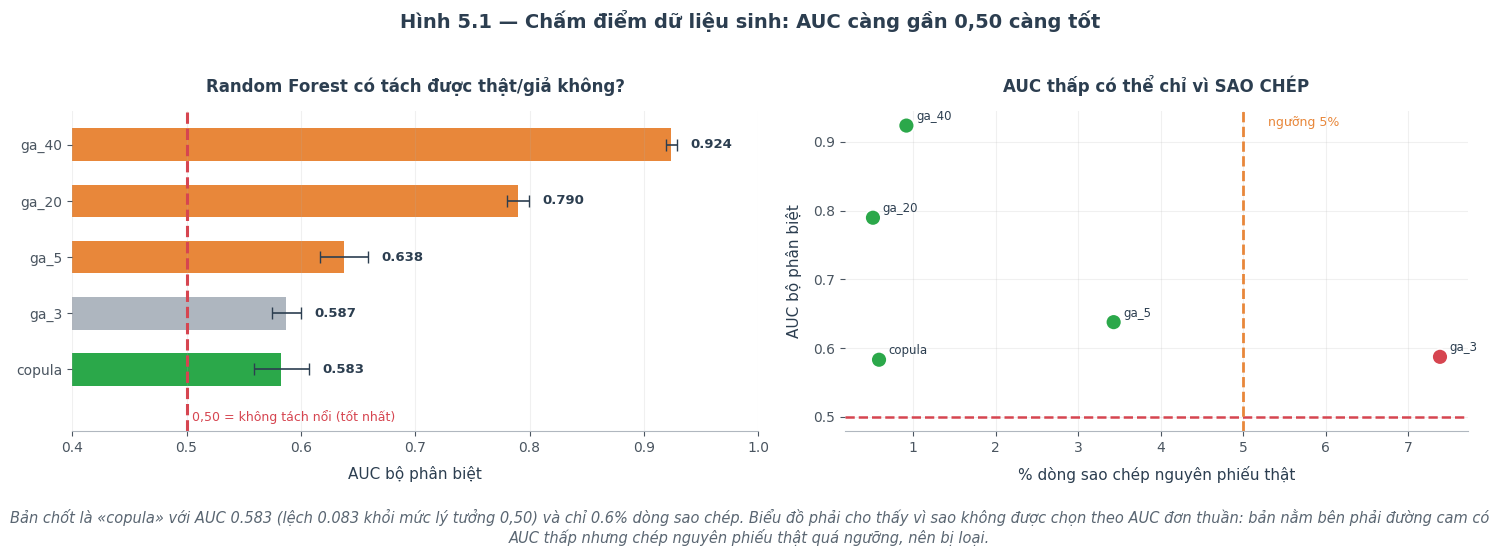

In [3]:
# ═══════════ HÌNH 5.1 — Bộ phân biệt ═══════════
fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 4.8),
                             gridspec_kw={"width_ratios": [1.1, 1]})
yy = np.arange(len(bao_cao))
mau = [C_XAM if not h else (C_GA if abs(a - .5) < .10 else C_CAM)
       for h, a in zip(bao_cao.hop_le, bao_cao.auc)]
a1.barh(yy, bao_cao.auc, xerr=bao_cao.auc_sd, color=mau, height=.58,
        error_kw=dict(ecolor=C_DAM, lw=1.2, capsize=4))
a1.axvline(.5, color=C_THAT, ls="--", lw=2.2)
# Chú thích đặt DƯỚI cột thấp nhất — đặt phía trên thì đè lên cột trên cùng
a1.set_ylim(-1.1, len(bao_cao) - .4)
a1.text(.505, -.85, "0,50 = không tách nổi (tốt nhất)", fontsize=9, color=C_THAT,
        va="center")
a1.set_yticks(yy); a1.set_yticklabels(bao_cao.ban, fontsize=10)
a1.set_xlabel("AUC bộ phân biệt"); a1.set_xlim(.4, 1.0)
a1.grid(axis="y", alpha=0)
a1.set_title("Random Forest có tách được thật/giả không?", fontsize=12)
for i, (a, s) in enumerate(zip(bao_cao.auc, bao_cao.auc_sd)):
    a1.text(a + s + .012, i, f"{a:.3f}", va="center", fontweight="bold", fontsize=9.5)

a2.scatter(bao_cao.sao_chep * 100, bao_cao.auc, s=130,
           color=[C_GA if h else C_THAT for h in bao_cao.hop_le],
           edgecolor="white", lw=1.2, zorder=3)
for r in bao_cao.itertuples():
    a2.annotate(r.ban, (r.sao_chep * 100, r.auc), fontsize=8.5,
                xytext=(7, 4), textcoords="offset points")
a2.axhline(.5, color=C_THAT, ls="--", lw=1.8)
a2.axvline(NGUONG_SAO_CHEP * 100, color=C_CAM, ls="--", lw=2)
a2.text(NGUONG_SAO_CHEP * 100 + .3, bao_cao.auc.max(),
        f"ngưỡng {NGUONG_SAO_CHEP:.0%}", fontsize=9, color=C_CAM)
a2.set_xlabel("% dòng sao chép nguyên phiếu thật")
a2.set_ylabel("AUC bộ phân biệt")
a2.set_title("AUC thấp có thể chỉ vì SAO CHÉP", fontsize=12)

fig.suptitle("Hình 5.1 — Chấm điểm dữ liệu sinh: AUC càng gần 0,50 càng tốt",
             fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
luu(fig, OUT, "hinh_5_1_phan_biet.png",
    f"Bản chốt là «{tot.ban}» với AUC {tot.auc:.3f} (lệch {tot.lech_05:.3f} khỏi mức lý "
    f"tưởng 0,50) và chỉ {tot.sao_chep:.1%} dòng sao chép. Biểu đồ phải cho thấy vì sao "
    f"không được chọn theo AUC đơn thuần: bản nằm bên phải đường cam có AUC thấp nhưng "
    f"chép nguyên phiếu thật quá ngưỡng, nên bị loại.")
plt.show()

   💾 hinh_5_2_ks.png


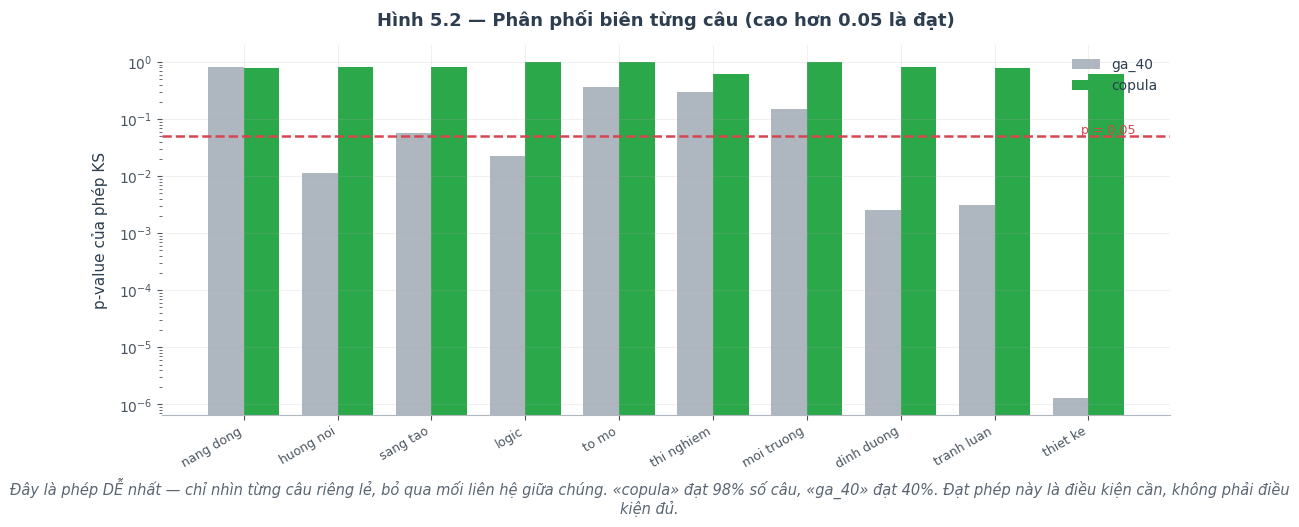

In [4]:
# ═══════════ HÌNH 5.2 — KS từng câu ═══════════
fig, ax = plt.subplots(figsize=(13, 4.8))
x = np.arange(len(L)); w_ = .38
for j, (t_, mau_) in enumerate([(xau.ban, C_XAM), (tot.ban, C_GA)]):
    rng = np.random.default_rng(SEED)
    M_ = SINH[t_]
    Gi = M_[rng.choice(len(M_), len(Lk_ks), replace=False)]
    p = [ks_2samp(Lk_ks[:, c], Gi[:, c]).pvalue for c in range(len(L))]
    ax.bar(x + (j - .5) * w_, p, w_, color=mau_, label=t_)
ax.axhline(.05, color=C_THAT, ls="--", lw=1.8)
ax.text(len(L) - .5, .055, "p = 0.05", fontsize=9, color=C_THAT, ha="right")
ax.set_xticks(x)
ax.set_xticklabels([c.replace("likert_", "").replace("_", " ") for c in L],
                   rotation=30, ha="right", fontsize=9)
ax.set_ylabel("p-value của phép KS"); ax.set_yscale("log"); ax.legend(fontsize=10)
ax.set_title("Hình 5.2 — Phân phối biên từng câu (cao hơn 0.05 là đạt)")
luu(fig, OUT, "hinh_5_2_ks.png",
    f"Đây là phép DỄ nhất — chỉ nhìn từng câu riêng lẻ, bỏ qua mối liên hệ giữa chúng. "
    f"«{tot.ban}» đạt {tot.ks_dat:.0%} số câu, «{xau.ban}» đạt {xau.ks_dat:.0%}. Đạt phép "
    f"này là điều kiện cần, không phải điều kiện đủ.")
plt.show()

   💾 hinh_5_3_tuong_quan.png


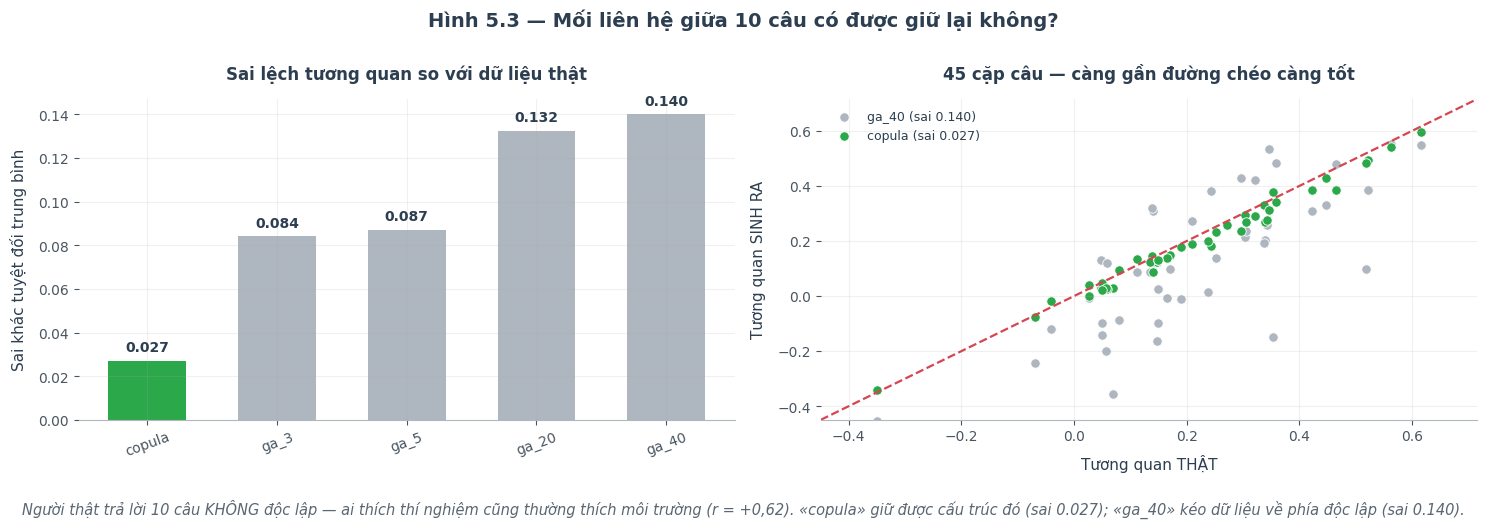

In [5]:
# ═══════════ HÌNH 5.3 — Cấu trúc tương quan ═══════════
iu = np.triu_indices(len(L), 1)
r_that = np.corrcoef(Lk_ks.T)[iu]
sai = {t: np.abs(np.corrcoef(SINH[t].T)[iu] - r_that).mean() for t in TEN_PP}

fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 4.8))
a1.bar(TEN_PP, [sai[t] for t in TEN_PP],
       color=[C_GA if t == tot.ban else C_XAM for t in TEN_PP], width=.6)
nhan_doc(a1, fmt="{:.3f}")
a1.set_ylabel("Sai khác tuyệt đối trung bình")
a1.set_title("Sai lệch tương quan so với dữ liệu thật", fontsize=12)
a1.tick_params(axis="x", rotation=20)

a2.scatter(r_that, np.corrcoef(SINH[xau.ban].T)[iu], s=46, color=C_XAM,
           label=f"{xau.ban} (sai {sai[xau.ban]:.3f})", edgecolor="white", lw=.6)
a2.scatter(r_that, np.corrcoef(SINH[tot.ban].T)[iu], s=46, color=C_GA,
           label=f"{tot.ban} (sai {sai[tot.ban]:.3f})", edgecolor="white", lw=.6)
lim = [r_that.min() - .1, r_that.max() + .1]
a2.plot(lim, lim, "--", color=C_THAT, lw=1.6)
a2.set_xlim(lim); a2.set_ylim(lim); a2.legend(fontsize=9)
a2.set_xlabel("Tương quan THẬT"); a2.set_ylabel("Tương quan SINH RA")
a2.set_title("45 cặp câu — càng gần đường chéo càng tốt", fontsize=12)

fig.suptitle("Hình 5.3 — Mối liên hệ giữa 10 câu có được giữ lại không?",
             fontsize=14, fontweight="bold", y=1.0)
fig.tight_layout()
luu(fig, OUT, "hinh_5_3_tuong_quan.png",
    f"Người thật trả lời 10 câu KHÔNG độc lập — ai thích thí nghiệm cũng thường thích "
    f"môi trường (r = +0,62). «{tot.ban}» giữ được cấu trúc đó (sai {sai[tot.ban]:.3f}); "
    f"«{xau.ban}» kéo dữ liệu về phía độc lập (sai {sai[xau.ban]:.3f}).")
plt.show()

   💾 hinh_5_4_nam_chi_so.png


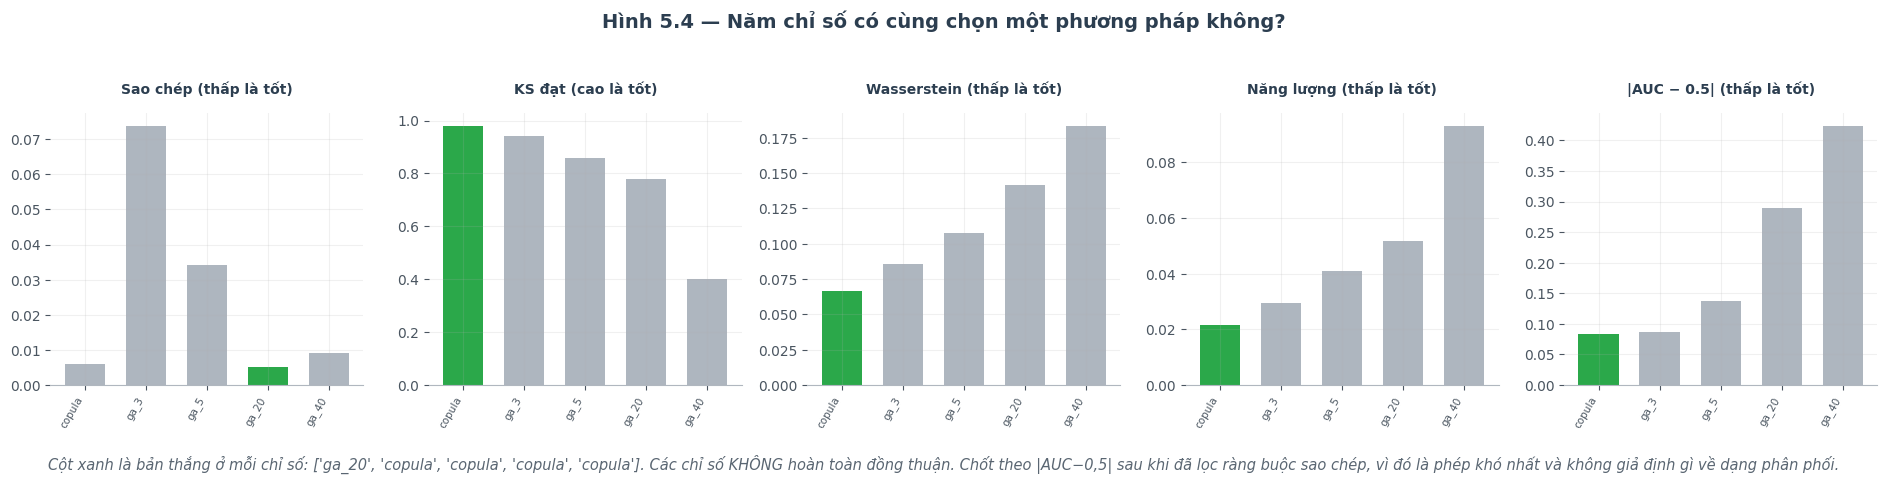

In [6]:
# ═══════════ HÌNH 5.4 — Năm chỉ số có cùng kết luận không ═══════════
fig, axes = plt.subplots(1, 5, figsize=(19, 4.2))
chi_so = [("sao_chep", "Sao chép (thấp là tốt)", False),
          ("ks_dat", "KS đạt (cao là tốt)", True),
          ("wasserstein", "Wasserstein (thấp là tốt)", False),
          ("nang_luong", "Năng lượng (thấp là tốt)", False),
          ("lech_05", "|AUC − 0.5| (thấp là tốt)", False)]
thang = []
for ax, (cot, ten_, cao_tot) in zip(axes, chi_so):
    v = bao_cao[cot].values
    i_t = int(v.argmax() if cao_tot else v.argmin())
    thang.append(bao_cao.ban.iloc[i_t])
    ax.bar(range(len(bao_cao)), v,
           color=[C_GA if i == i_t else C_XAM for i in range(len(bao_cao))], width=.66)
    ax.set_xticks(range(len(bao_cao)))
    ax.set_xticklabels(bao_cao.ban, rotation=60, ha="right", fontsize=7.5)
    ax.set_title(ten_, fontsize=10)
fig.suptitle("Hình 5.4 — Năm chỉ số có cùng chọn một phương pháp không?",
             fontsize=14, fontweight="bold", y=1.04)
fig.tight_layout()
luu(fig, OUT, "hinh_5_4_nam_chi_so.png",
    f"Cột xanh là bản thắng ở mỗi chỉ số: {thang}. "
    + (f"Cả năm chỉ số cùng chọn «{thang[0]}» — kết luận vững, không phải may mắn ở "
       f"một phép đo."
       if len(set(thang)) == 1 else
       "Các chỉ số KHÔNG hoàn toàn đồng thuận. Chốt theo |AUC−0,5| sau khi đã lọc ràng "
       "buộc sao chép, vì đó là phép khó nhất và không giả định gì về dạng phân phối."))
plt.show()

## 2. Chốt bản dùng

In [7]:
# Ghi bảng CHỐT — Giai đoạn 6 đọc đúng file này, khỏi phải tự chọn lại
b = khung.copy()
for i, c in enumerate(L):
    b[c] = SINH[tot.ban][:, i].astype(int)
b["gioi_tinh"] = np.where(GT > .5, "Nam", "Nữ")
b["muc_tieu_ma"] = MT
b.to_csv(OUT / "ttth_da_sinh.csv", index=False)

ket_luan = {
    "phuong_phap_chot": tot.ban,
    "file_dung": "05_KiemDinhDuLieuSinh/ttth_da_sinh.csv",
    "auc": float(tot.auc), "auc_sd": float(tot.auc_sd),
    "lech_khoi_05": float(tot.lech_05),
    "sao_chep": float(tot.sao_chep), "nguong_sao_chep": NGUONG_SAO_CHEP,
    "da_dang": float(tot.da_dang), "da_dang_that": float(dd_that),
    "ks_dat": float(tot.ks_dat),
    "wasserstein": float(tot.wasserstein), "nang_luong": float(tot.nang_luong),
    "ban_bi_loai_vi_sao_chep": list(loai.ban),
    "canh_bao": ("Bộ sinh ĐÃ THẤY cả 676 phiếu dùng để chấm (chưa chia train/test "
                 "ở giai đoạn này) — đây là cận trên lạc quan."),
}
(OUT / "ket_luan.json").write_text(
    json.dumps(ket_luan, ensure_ascii=False, indent=2), encoding="utf-8")

tom_tat("GIAI ĐOẠN 5 — KIỂM ĐỊNH DỮ LIỆU SINH", [
    f"Chấm                   {len(TEN_PP)} phương pháp",
    f"Loại vì sao chép ≥{NGUONG_SAO_CHEP:.0%}  {list(loai.ban) if len(loai) else 'không có'}",
    "",
    f"CHỐT                   {tot.ban}",
    f"   AUC bộ phân biệt    {tot.auc:.3f} ± {tot.auc_sd:.3f}"
    f"   (lệch {tot.lech_05:.3f} khỏi mức lý tưởng 0,50)",
    f"   sao chép phiếu thật {tot.sao_chep:.1%}   (ngưỡng {NGUONG_SAO_CHEP:.0%})",
    f"   đa dạng             {tot.da_dang:.1%}   (khảo sát thật {dd_that:.1%})",
    f"   KS đạt              {tot.ks_dat:.0%} số câu",
    f"   Wasserstein         {tot.wasserstein:.3f}",
    f"   năng lượng          {tot.nang_luong:.3f}",
    "",
    f"Tệ nhất                {xau.ban}  (AUC {xau.auc:.3f})",
    "",
    "⚠️  Cận trên lạc quan — bộ sinh đã thấy dữ liệu dùng để chấm",
    "⚠️  Giai đoạn 8 BẮT BUỘC có mốc 'chỉ 676 phiếu thật, không dùng dữ liệu sinh'",
])
print(f"\n✅ bao_cao_kiem_dinh.csv · ttth_da_sinh.csv · ket_luan.json · 4 hình  →  {OUT}")

╔════════════════════════════════════════════════════════════════════════════╗
║                    GIAI ĐOẠN 5 — KIỂM ĐỊNH DỮ LIỆU SINH                    ║
╠════════════════════════════════════════════════════════════════════════════╣
║ Chấm                   5 phương pháp                                       ║
║ Loại vì sao chép ≥5%  ['ga_3']                                             ║
║                                                                            ║
║ CHỐT                   copula                                              ║
║    AUC bộ phân biệt    0.583 ± 0.024   (lệch 0.083 khỏi mức lý tưởng 0,50) ║
║    sao chép phiếu thật 0.6%   (ngưỡng 5%)                                  ║
║    đa dạng             96.3%   (khảo sát thật 97.6%)                       ║
║    KS đạt              98% số câu                                          ║
║    Wasserstein         0.067                                               ║
║    năng lượng          0.022                      